# Corridor Demand Profile — Survey-Only 2022 Matrices (Total and Transit)

Directional link-flow profiles along the LRT corridor for the **2022 three-mode matrices** of `THS_2017_three_mode_2022.ipynb`, built the same way as the profile of the leveled hybrid-based matrix (`Output/transit/corridor_link_flows_2022.csv`, commit 7d07a91):

- the corridor areas (`IsLRT_Corridor = 1` in `Input/Submatrix_tazs.xlsx`) in `AggAreaCode` order form the line sequence — the same 18 areas as before (Adi, Alon Hagalil and Tzipori, which the earlier 25-area matrix had filtered out as noise, are left out for comparability);
- every OD pair with **both ends on the sequence** is assigned to every link between its origin and destination, in the direction of travel — direction 1 → 23 is Tirat Carmel → Nazareth, 23 → 1 the reverse;
- two profiles: **total** = car + bus + rail, and **transit only** = bus (calibrated public bus + Matronit + taxi-type) + rail (survey, door-to-door).

The earlier hybrid-based profiles are drawn as dashed lines for comparison. Their transit layer was the RavKav × OnBoard bus matrix plus the station-based train matrix, so differences in the transit profile reflect both the source (survey vs ticketing frame) and the calibration.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
IN = 'Output/ths2017/three_mode_2022'; OUT = IN
os.makedirs('Output/figures', exist_ok=True)

def load_area(name):
    m = pd.read_csv(f'{IN}/{name}_2022_area.csv', index_col=0); m.index = m.index.astype(int); m.columns = m.columns.astype(int); return m
car, bus, rail = load_area('car'), load_area('bus'), load_area('rail')
total, transit = car + bus + rail, bus + rail
legend = pd.read_csv('Output/ths2017/study_taz/study_taz_area_legend.csv' if os.path.exists('Output/ths2017/study_taz/study_taz_area_legend.csv') else 'Output/ths2017/study_taz/submatrices/area_legend.csv').set_index('AggAreaCode')
ref_total = pd.read_csv('Output/transit/corridor_link_flows_2022.csv')
ref_transit = pd.read_csv('Output/transit/corridor_link_flows_transit_2022.csv')
SEQ = list(ref_total['from_code']) + [int(ref_total['to_code'].iloc[-1])]          # the same 18-area line sequence as the earlier profile
assert all(legend.loc[a, 'IsLRT_Corridor'] == 1 for a in SEQ)
names = legend['AggAreaName']
print("line sequence:", ' → '.join(f'{a} {names[a]}' for a in SEQ))
print(f"2022 area matrices: total {total.values.sum():,.0f} trips in the 28 sub-areas (car {car.values.sum():,.0f}, bus {bus.values.sum():,.0f}, rail {rail.values.sum():,.0f})")

line sequence: 1 TiratCarmel → 2 Matam → 3 Neot Peres → 4 Neve David → 5 Ein Hayam → 6 Bat Galim → 7 Kiryat Eliezer → 8 Hamoshava → 9 Lower City → 10 Hadar Carmel → 11 Namal → 12 Neve Yosef → 13 Hamifrats → 14 Hutzot → 16 Kiryat Ata Center → 17 Kiryat Bialik South → 19 Shefaram → 23 Nazareth Area
2022 area matrices: total 214,360 trips in the 28 sub-areas (car 182,374, bus 31,882, rail 104)


## Link flows

In [2]:
def link_flows(m, seq):
    pos = {a: i for i, a in enumerate(seq)}
    sub = m.reindex(index=seq, columns=seq).fillna(0).values
    n = len(seq); f_fwd, f_bwd = np.zeros(n - 1), np.zeros(n - 1)
    for i in range(n):
        for j in range(n):
            if i < j: f_fwd[i:j] += sub[i, j]          # links i..j-1 in direction 1 -> 23
            elif i > j: f_bwd[j:i] += sub[i, j]        # links j..i-1 in direction 23 -> 1
    out = pd.DataFrame({'from_code': seq[:-1], 'to_code': seq[1:], 'from_area': [names[a] for a in seq[:-1]], 'to_area': [names[a] for a in seq[1:]],
                        'flow_dir_1_to_23': f_fwd.round(0), 'flow_dir_23_to_1': f_bwd.round(0)})
    out['total_both_dir'] = out['flow_dir_1_to_23'] + out['flow_dir_23_to_1']
    internal = sub[~np.eye(n, dtype=bool)].sum() + np.trace(sub)
    return out, internal

prof_total, int_total = link_flows(total, SEQ)
prof_transit, int_transit = link_flows(transit, SEQ)
prof_total.to_csv(f'{OUT}/corridor_link_flows_total_2022.csv', index=False)
prof_transit.to_csv(f'{OUT}/corridor_link_flows_transit_2022.csv', index=False)
for name, p, internal, ref, tot in [('total (car + bus + rail)', prof_total, int_total, ref_total, total), ('transit (bus + rail)', prof_transit, int_transit, ref_transit, transit)]:
    k = p['total_both_dir'].idxmax()
    print(f"{name}: corridor-internal demand {internal:,.0f} of {tot.values.sum():,.0f} sub-area trips; peak link {p.loc[k, 'from_area']} – {p.loc[k, 'to_area']} "
          f"({p.loc[k, 'flow_dir_1_to_23']:,.0f} / {p.loc[k, 'flow_dir_23_to_1']:,.0f}); earlier hybrid-based peak {ref['total_both_dir'].max():,.0f} both directions")
cmp = prof_total[['from_area', 'to_area', 'flow_dir_1_to_23', 'flow_dir_23_to_1']].copy()
cmp.columns = ['from', 'to', 'total 1→23', 'total 23→1']
cmp['hybrid-based 1→23'] = ref_total['flow_dir_1_to_23']; cmp['hybrid-based 23→1'] = ref_total['flow_dir_23_to_1']
cmp['transit 1→23'] = prof_transit['flow_dir_1_to_23']; cmp['transit 23→1'] = prof_transit['flow_dir_23_to_1']
cmp['ticketing-based transit 1→23'] = ref_transit['flow_dir_1_to_23']; cmp['ticketing-based transit 23→1'] = ref_transit['flow_dir_23_to_1']
cmp['transit share 1→23'] = cmp['transit 1→23'] / cmp['total 1→23']; cmp['transit share 23→1'] = cmp['transit 23→1'] / cmp['total 23→1']
cmp.to_csv(f'{OUT}/corridor_link_flows_comparison_2022.csv', index=False, float_format='%.3f')
cmp.round(2)

total (car + bus + rail): corridor-internal demand 69,655 of 214,360 sub-area trips; peak link Bat Galim – Kiryat Eliezer (6,862 / 6,458); earlier hybrid-based peak 15,247 both directions
transit (bus + rail): corridor-internal demand 10,770 of 31,986 sub-area trips; peak link Ein Hayam – Bat Galim (2,966 / 1,457); earlier hybrid-based peak 4,240 both directions


,from,to,total 1→23,total 23→1,hybrid-based 1→23,hybrid-based 23→1,transit 1→23,transit 23→1,ticketing-based transit 1→23,ticketing-based transit 23→1,transit share 1→23,transit share 23→1
0,TiratCarmel,Matam,4121.0,1549.0,5085.0,1075.0,1267.0,571.0,776.0,192.0,0.31,0.37
1,Matam,Neot Peres,3380.0,3401.0,4136.0,2358.0,1337.0,1208.0,1047.0,419.0,0.40,0.36
2,Neot Peres,Neve David,3272.0,4133.0,3924.0,3194.0,1220.0,1837.0,1037.0,874.0,0.37,0.44
3,Neve David,Ein Hayam,4993.0,4092.0,6152.0,4746.0,2070.0,1717.0,1632.0,1629.0,0.41,0.42
4,Ein Hayam,Bat Galim,7216.0,3496.0,6761.0,3913.0,2966.0,1457.0,1853.0,1648.0,0.41,0.42
5,Bat Galim,Kiryat Eliezer,6862.0,6458.0,7671.0,7576.0,2541.0,1627.0,1656.0,2584.0,0.37,0.25
6,Kiryat Eliezer,Hamoshava,6881.0,4735.0,7103.0,6025.0,2322.0,1240.0,1554.0,2398.0,0.34,0.26
7,Hamoshava,Lower City,5880.0,3500.0,5911.0,4629.0,2430.0,1337.0,1461.0,2326.0,0.41,0.38
8,Lower City,Hadar Carmel,4557.0,4255.0,5635.0,6060.0,1759.0,1571.0,1175.0,2736.0,0.39,0.37
9,Hadar Carmel,Namal,3065.0,3793.0,3856.0,4870.0,1240.0,1624.0,725.0,2652.0,0.40,0.43


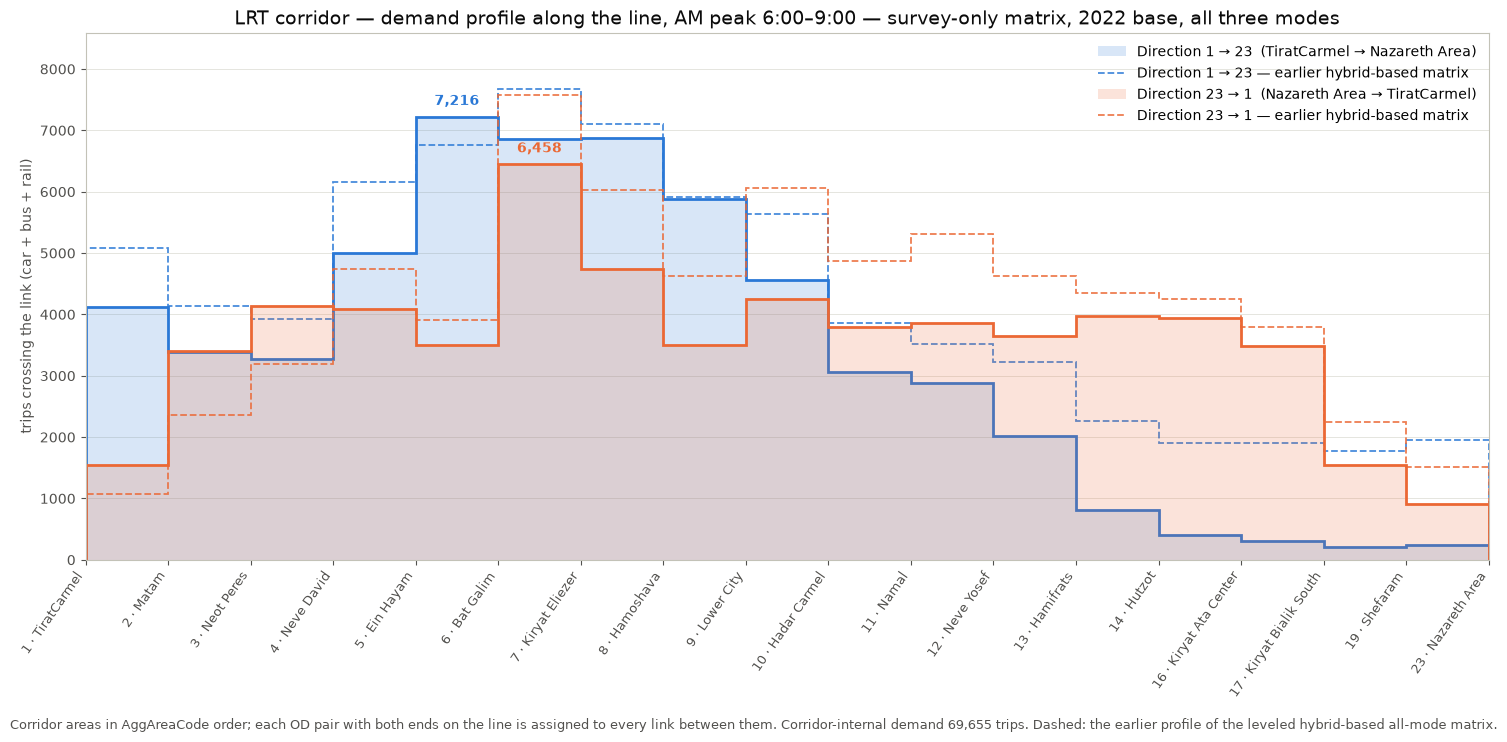

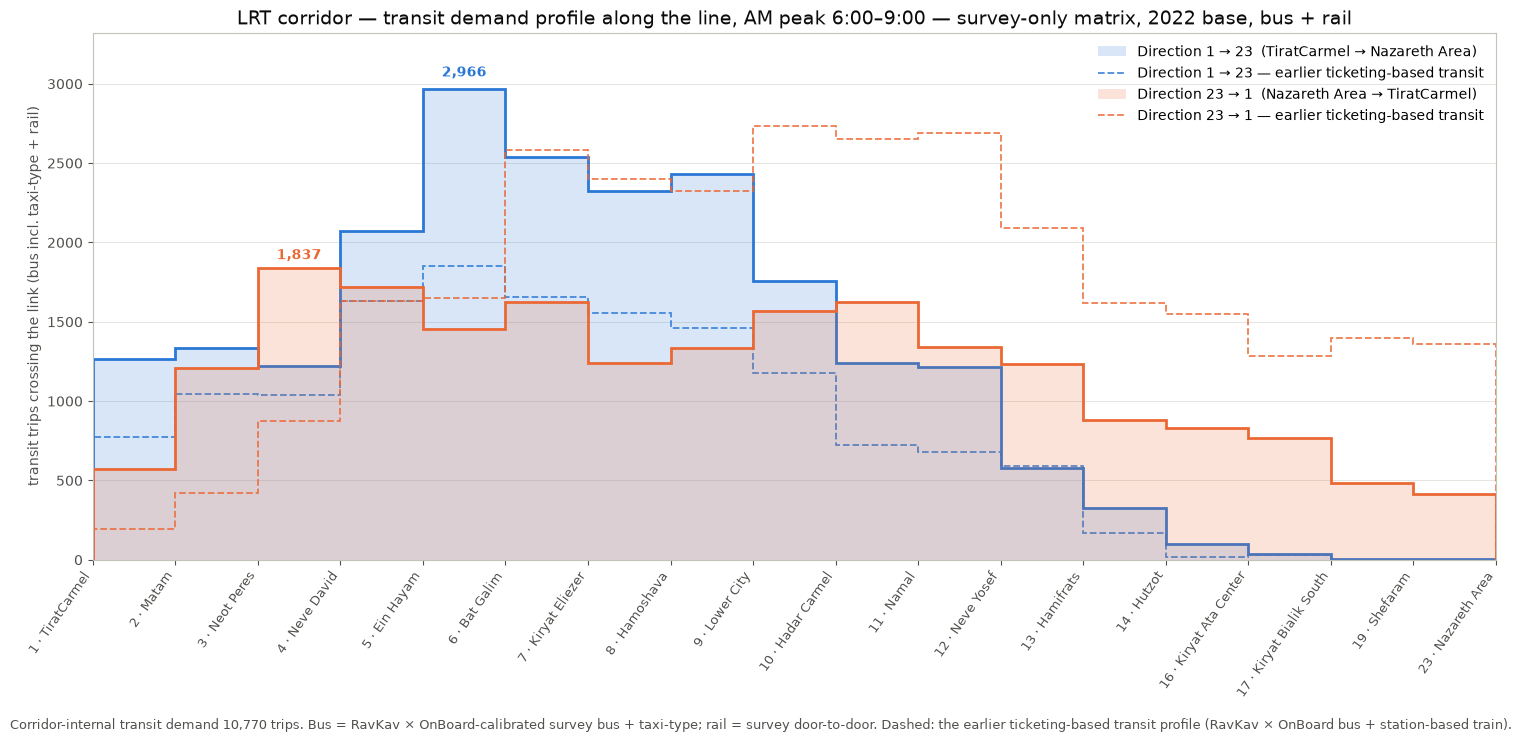

In [3]:
def profile_chart(p, ref, title, ylabel, fname, note, ref_label='earlier hybrid-based matrix'):
    n = len(p) + 1; x = np.arange(n)
    fig, ax = plt.subplots(figsize=(15, 7.2), facecolor='white')
    for col, color, lab in [('flow_dir_1_to_23', BLUE, f'Direction 1 → 23  ({names[SEQ[0]]} → {names[SEQ[-1]]})'), ('flow_dir_23_to_1', ORANGE, f'Direction 23 → 1  ({names[SEQ[-1]]} → {names[SEQ[0]]})')]:
        y = p[col].values
        ax.stairs(y, x, color=color, linewidth=2, label=lab, baseline=0, fill=True, alpha=0.18)
        ax.stairs(y, x, color=color, linewidth=2)
        ax.stairs(ref[col].values, x, color=color, linewidth=1.3, linestyle='--', alpha=0.85, label=lab.split('  ')[0] + ' — ' + ref_label)
        k = int(np.argmax(y)); ax.text(k + 0.5, y[k] * 1.02, f'{y[k]:,.0f}', ha='center', va='bottom', color=color, fontsize=10, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([f'{a} · {names[a]}' for a in SEQ], rotation=55, ha='right', fontsize=9, color=INK2)
    ax.set_xlim(0, n - 1); ax.set_ylim(0, max(p[['flow_dir_1_to_23', 'flow_dir_23_to_1']].values.max(), ref[['flow_dir_1_to_23', 'flow_dir_23_to_1']].values.max()) * 1.12)
    ax.grid(True, color=GRID, linewidth=0.6, axis='y'); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2); ax.set_ylabel(ylabel, color=INK2); ax.set_title(title, color=INK, fontsize=14)
    ax.legend(frameon=False, fontsize=10, loc='upper right')
    fig.text(0.5, -0.02, note, ha='center', color=INK2, fontsize=9)
    plt.tight_layout(); fig.savefig(f'Output/figures/{fname}', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

profile_chart(prof_total, ref_total, 'LRT corridor — demand profile along the line, AM peak 6:00–9:00 — survey-only matrix, 2022 base, all three modes',
              'trips crossing the link (car + bus + rail)', 'corridor_flow_profile_total_survey2022.png',
              f'Corridor areas in AggAreaCode order; each OD pair with both ends on the line is assigned to every link between them. Corridor-internal demand {int_total:,.0f} trips. '
              'Dashed: the earlier profile of the leveled hybrid-based all-mode matrix.')
profile_chart(prof_transit, ref_transit, 'LRT corridor — transit demand profile along the line, AM peak 6:00–9:00 — survey-only matrix, 2022 base, bus + rail',
              'transit trips crossing the link (bus incl. taxi-type + rail)', 'corridor_flow_profile_transit_survey2022.png',
              f'Corridor-internal transit demand {int_transit:,.0f} trips. Bus = RavKav × OnBoard-calibrated survey bus + taxi-type; rail = survey door-to-door. '
              'Dashed: the earlier ticketing-based transit profile (RavKav × OnBoard bus + station-based train).', ref_label='earlier ticketing-based transit')

## Notes

- **Same construction, different matrices.** The earlier profile used the leveled hybrid-based all-mode matrix (survey car / other Furnessed to 2022 + RavKav × OnBoard bus + train). This one uses the survey-only car / bus / rail set: car from the trips file grown to 2022, bus calibrated to ticketing where ticketing coverage is credible, rail from the survey. Differences in the total profile come mostly from the car layer's source (population / employment TAZ split, no cellular structure) and from the "other" modes, which the earlier matrix included and this one does not.
- **Transit frame.** The survey bus layer starts trips at the doorstep; the ticketing matrix starts them at the boarding stop, so hub areas (Hamifrats, Neve Yosef) draw more flow in the ticketing-based profile than here.
- **Corridor-internal only.** Trips with one end off the line are not on the profile; the extended market of `NoBuild_and_LRT_market.ipynb` covers them.